Лабораторна робота №7
Шарамко Богдан Вадимович ФІТ 2-17
Варіант 20

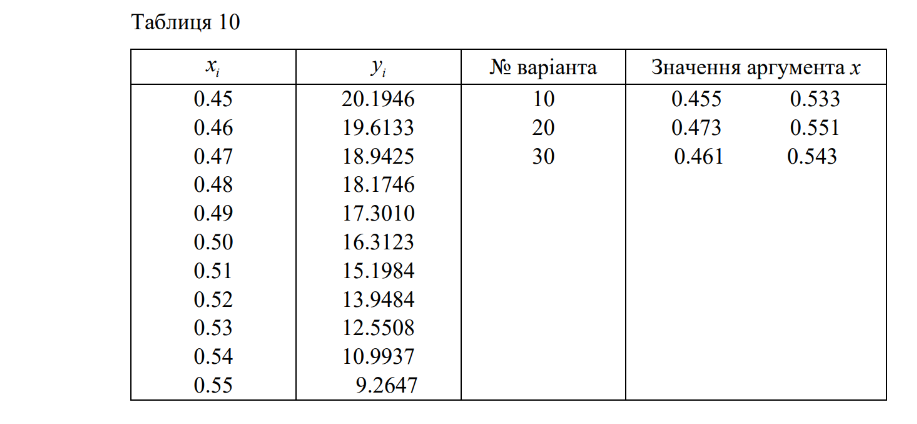

In [ ]:
import numpy as np
from math import factorial

x = np.array([0.45, 0.46, 0.47, 0.48, 0.49, 0.50, 0.51, 0.52, 0.53, 0.54, 0.55])
y = np.array([20.1946, 19.6133, 18.9425, 18.1746, 17.3010, 16.3123, 15.1984, 13.9484, 12.5508, 10.9937, 9.2647])

print("x =", x)
print("y =", y)

def newton_forward_interpolation(x, y, x0):
    n = len(x)
    h = x[1] - x[0]

    delta_y = np.zeros((n, n))
    delta_y[:, 0] = y

    for j in range(1, n):
        for i in range(n - j):
            delta_y[i, j] = delta_y[i + 1, j - 1] - delta_y[i, j - 1]

    start_index = 2

    q = (x0 - x[start_index]) / h

    ans = delta_y[start_index, 0]
    q_prod = 1

    for i in range(1, n - start_index):
        q_prod *= (q - i + 1)
        ans += (q_prod * delta_y[start_index, i]) / factorial(i)

    return ans

x1 = 0.473

y1 = newton_forward_interpolation(x, y, x1)

print(f"f({x1}) = {y1:.4f}")

x = [0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55]
y = [20.1946 19.6133 18.9425 18.1746 17.301  16.3123 15.1984 13.9484 12.5508
 10.9937  9.2647]
f(0.473) = 18.7227


In [ ]:
def newton_backward_interpolation(x, y, x0):
    n = len(x)
    h = x[1] - x[0]

    delta_y = np.zeros((n, n))
    delta_y[:, 0] = y

    for j in range(1, n):
        for i in range(n - j):
            delta_y[i, j] = delta_y[i+1, j-1] - delta_y[i, j-1]

    q = (x0 - x[-1]) / h

    ans = delta_y[-1, 0]
    q_prod = 1

    for i in range(1, n):
        q_prod *= (q + i - 1)
        ans += (q_prod * delta_y[n - i - 1, i]) / factorial(i)

    return ans

x2 = 0.227

y2 = newton_backward_interpolation(x, y, x2)

print(f"f({x2}) = {y2:.4f}")

f(0.227) = 134503.9303


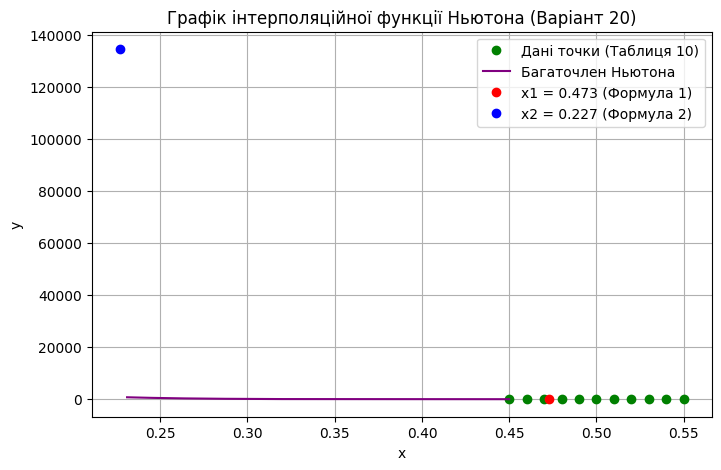

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

xx = np.linspace(np.min(x), x2 + 0.004, 200)
yy = np.zeros_like(xx)

for i in range(len(xx)):
    if xx[i] <= 0.50:
        yy[i] = newton_forward_interpolation(x, y, xx[i])
    else:
        yy[i] = newton_backward_interpolation(x, y, xx[i])

plt.figure(figsize=(8, 5))
plt.plot(x, y, 'o', color='green', label='Дані точки (Таблиця 10)')
plt.plot(xx, yy, '-', color='purple', label='Багаточлен Ньютона')
plt.plot(x1, y1, 'ro', label=f'x1 = {x1} (Формула 1)')
plt.plot(x2, y2, 'bo', label=f'x2 = {x2} (Формула 2)')

plt.title("Графік інтерполяційної функції Ньютона (Варіант 20)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()